In [15]:
import os
import typing
#from functool import cache 
from datasets import load_dataset, Dataset, IterableDataset
from functools import reduce
chime_path = "/home/niklas/Downloads/Datasets/CHIME6/CHiME6_eval/CHiME6/audio/eval"
#dipco_path = "/home/niklas/Downloads/Datasets/Dipco/"

import os
from datasets import Dataset, Audio
import pandas as pd


'''def create_dipco_from_directory(directory_path, output_path):
    dev_path = os.path.join(dipco_path, 'audio/dev')
    transcript_dev_path = os.path.join(dipco_path, 'transcriptions/dev')
    #dev_audio_files = [os.path.join(directory_path, os.path.join(dev_path, file)) for file in os.listdir(dev_path) if file.endswith(('.wav', '.mp3', '.flac'))]
    dev_transcript_files = [os.path.join(transcript_dev_path, file) for file in os.listdir(transcript_dev_path) if file.endswith(('.json'))]
    print(dev_transcript_files[0])
    df_devs = [pd.read_json(jsonfile) for jsonfile in dev_transcript_files]
 
    final_dev = reduce(lambda left,right: pd.merge(left,right, on=['labels'], how='outer'), df_devs)
    
    #df = pd.DataFrame(dev_audio_files, columns=["file_path"])
    #dataset = Dataset.from_pandas(df)
    #dataset = dataset.cast_column("file_path", Audio(sampling_rate=16000))
    
    #dataset.save_to_disk(output_path)
/export/data2/nbaier/espnet/egs2/chime7_task1/asr1/dataset/ChiME6
/project/data_asr/dipco/Dipco
directory_path = dipco_path
output_path = dipco_path
create_dipco_from_directory(directory_path, output_path)'''

    
"""
def create_audio_dataset_from_directory(directory_path, output_path):
    
    Create a Hugging Face dataset from a directory of audio files.

    Args:
        directory_path (str): Path to the directory containing audio files.
        output_path (str): Path to save the output dataset.
    
    # Get all audio file paths
    audio_files = [os.path.join(directory_path, file) for file in os.listdir(directory_path) if file.endswith(('.wav', '.mp3', '.flac'))]

    # Create a dataframe with file paths
    df = pd.DataFrame(audio_files, columns=["file_path"])
 
    # Convert dataframe to Hugging Face dataset
    dataset = Dataset.from_pandas(df)

    # Cast the 'file_path' column to 'audio' feature type
    dataset = dataset.cast_column("file_path", Audio(sampling_rate=16000))

    # Save the dataset
    dataset.save_to_disk(output_path)

    print(f"Dataset saved to {output_path}")

# Usage
directory_path = chime_path
output_path = os.getcwd()
create_audio_dataset_from_directory(directory_path, output_path)

"""



'\ndef create_audio_dataset_from_directory(directory_path, output_path):\n    \n    Create a Hugging Face dataset from a directory of audio files.\n\n    Args:\n        directory_path (str): Path to the directory containing audio files.\n        output_path (str): Path to save the output dataset.\n    \n    # Get all audio file paths\n    audio_files = [os.path.join(directory_path, file) for file in os.listdir(directory_path) if file.endswith((\'.wav\', \'.mp3\', \'.flac\'))]\n\n    # Create a dataframe with file paths\n    df = pd.DataFrame(audio_files, columns=["file_path"])\n \n    # Convert dataframe to Hugging Face dataset\n    dataset = Dataset.from_pandas(df)\n\n    # Cast the \'file_path\' column to \'audio\' feature type\n    dataset = dataset.cast_column("file_path", Audio(sampling_rate=16000))\n\n    # Save the dataset\n    dataset.save_to_disk(output_path)\n\n    print(f"Dataset saved to {output_path}")\n\n# Usage\ndirectory_path = chime_path\noutput_path = os.getcwd()\ncre

In [39]:
import os  
import pandas as pd 
import torchaudio 
import re 
from typing import List
import glob
dipco_path = "/project/data_asr/dipco/Dipco"  
dataset_name = "Dipco"
dev_path = os.path.join(dipco_path, 'audio/dev')
transcript_dev_path = os.path.join(dipco_path, 'transcriptions/dev')


def extract_prefix(file_path:str) -> str:
    pattern = r'^(.*)\.json$'
    match = re.search(pattern, file_path)
    if match:
        prefix = match.group(1)
        return prefix
    else :
        raise ValueError
    




def list_json_files(directory):
    # Construct the file path pattern
    pattern = os.path.join(directory, '*.json')
    
    # Use glob to get a list of files matching the pattern
    json_files = glob.glob(pattern)
    
    return json_files

def load_and_concatenate_json_files(directory):
    json_files = list_json_files(directory)
    
    # List to hold individual DataFrames
    data_frames = []
    
    for json_file in json_files:
        # Read the JSON file into a DataFrame
        df = pd.read_json(json_file)
        data_frames.append(df)
    
    # Concatenate all DataFrames into a single DataFrame
    combined_df = pd.concat(data_frames, ignore_index=True)
    
    return combined_df


df = load_and_concatenate_json_files(transcript_dev_path)

#df = pd.read_json(full_path)
transcriptions = df['words']

print(df.columns)
print(df['start_time'].head(1))
#print(full_path)



ValueError: No objects to concatenate

In [40]:
from transformers import WhisperFeatureExtractor
from typing import Dict
import pprint
import torch 
import matplotlib.pyplot as plt 
import multiprocessing
model_name = "openai/whisper-small"
feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)
def expand_start_time(row):
    start_time_dict = row['start_time']
    rows = []
    for key, time_str in start_time_dict.items():
        new_row = row.copy()
        new_row['audio'] = key
        new_row['start'] = time_str
        rows.append(new_row)
    return pd.DataFrame(rows)


# Apply the function to each row and concatenate the results
expanded_df = pd.concat([expand_start_time(row) for _, row in df.iterrows()], ignore_index=True)

# Drop the original 'start_time' column
expanded_df = expanded_df.drop(columns=['start_time'])

# Function to convert time string to seconds
def time_to_seconds(time_str):
    h, m, s = map(float, time_str.split(':'))
    
    return h * 3600 + m * 60 + s

# Apply the conversion to the 'start' column
expanded_df['start'] = expanded_df['start'].apply(time_to_seconds)

def get_corresponding_end_time(dict:dict, key:str):
    end_time = [v for k,v in dict if k==key]
    return end_time
print(expanded_df.columns)
expanded_df['end'] = expanded_df.apply(lambda row: row['end_time'][row['audio']], axis=1)
expanded_df['end'] = expanded_df['end'].apply(time_to_seconds)
# removal of the end_time
expanded_df = expanded_df.drop(columns=['end_time'])
#expanded_df = expanded_df.drop(expanded_df['audio']=='close-talk')


# U01 - U05 & CH 1 - 7 

# Function to generate microphone paths
def generate_microphone_paths(row):
    paths = []
    for i in range(1, 7):
        path = f"{dev_path}/{row['session_id']}_{row['audio']}.CH{i}.wav"
        paths.append(path)

    path = f"{dev_path}/{row['session_id']}_{row['speaker_id']}.wav"
    paths.append(path)
    return paths

# Apply the function to generate the paths for each row
expanded_df['file_path'] = expanded_df.apply(generate_microphone_paths, axis=1)

# Expand the DataFrame to include the microphone paths
expanded_df = expanded_df.explode('file_path').reset_index(drop=True)


#change the seconds to frames
def get_Frames(starting_second:float, sample_rate:int, end_second:float )-> List[int] :
     return [int(starting_second*sample_rate), int(end_second*sample_rate)]

expanded_df['frames'] = expanded_df.apply(lambda row: get_Frames(row['start'], 16000, row['end']), axis=1)
expanded_df = expanded_df[expanded_df['audio'] != 'close-talk']
#columns_to_drop = ['mother_tongue', 'ref', 'nativeness', 'audio', 'session_id','speaker_id', 'gender']

#get the maximum speaking duration 
expanded_df['duration'] = expanded_df.apply(lambda row: row['end'] - row['start'], axis=1)
# print(expanded_df['duration'].max()) yielded that the biggest in the dipco dataset was above 60 seconds for those an additional separation is required 
#expanded_df = expanded_df.drop(columns=columns_to_drop)
# sorting for cache efficiency so far no speedup 
def validate_frames_column(frames_list):
    return len(frames_list) == 2
if expanded_df['frames'].isnull().any():
    raise ValueError("The 'frames' column contains null values.")
if not expanded_df['frames'].apply(validate_frames_column).all():
    raise ValueError("Each entry in the 'frames' column must be a list of exactly two elements [startframe, endframe].")

expanded_df[['startframe', 'endframe']] = pd.DataFrame(expanded_df['frames'].tolist(), index=expanded_df.index)

# Drop the original 'frames' column if no longer needed
"""expanded_df = expanded_df.drop(columns=['frames'])

expanded_df = expanded_df.sort_values(by=['file_path','start'])
expanded_df = expanded_df.reset_index(drop=True)
grouped = expanded_df.groupby(['words'])
count_df = grouped.size().reset_index(name='counts')
first_group_key = list(grouped.groups.keys())[0]
first_group = grouped.get_group(first_group_key)
print(first_group)
print(first_group['file_path'].value_counts())
print(count_df)"""

print(expanded_df.shape)
pprint.pp(expanded_df.head(10))

print(expanded_df.columns)
#expanded_df['logmel'] = expanded_df.apply(lambda row: get_logmel(row['startframe'], row['endframe'], row['file_path']), axis=1)
def get_logmel(startframe: int, endframe: int, filepath: str) -> Dict[str, torch.Tensor]:
    sliced_waveform = load_audio_segment(filepath=filepath, start_frame=startframe, end_frame=endframe)
    features = feature_extractor(sliced_waveform.numpy(), sampling_rate=16000, return_tensors='pt')
    return features


    
def load_audio_segment(filepath, start_frame, end_frame):
    waveform, sample_rate = torchaudio.load(filepath)
    return waveform[:, start_frame:end_frame], sample_rate    
#print(expanded_df)
#print(expanded_df.head(10))




Index(['end_time', 'words', 'ref', 'session_id', 'speaker_id', 'gender',
       'nativeness', 'mother_tongue', 'audio', 'start'],
      dtype='object')
(128555, 15)
         words         ref session_id speaker_id gender nativeness  \
0  speaker one  close-talk        S04        P13   male     native   
1  speaker one  close-talk        S04        P13   male     native   
2  speaker one  close-talk        S04        P13   male     native   
3  speaker one  close-talk        S04        P13   male     native   
4  speaker one  close-talk        S04        P13   male     native   
5  speaker one  close-talk        S04        P13   male     native   
6  speaker one  close-talk        S04        P13   male     native   
7  speaker one  close-talk        S04        P13   male     native   
8  speaker one  close-talk        S04        P13   male     native   
9  speaker one  close-talk        S04        P13   male     native   

  mother_tongue audio  start    end  \
0  U.S. English   U03  10

In [4]:
import torch
import cProfile
import time 
import functools
from transformers import WhisperFeatureExtractor
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")


dataset = Dataset.from_pandas(expanded_df.head(15))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Cast the 'file_path' column to 'audio' feature type
dataset = dataset.cast_column("file_path", Audio(sampling_rate=16000))
#print(dataset.features)
def load_audio_segment(filepath):
    waveform, sample_rate = torchaudio.load(filepath)
    return waveform, sample_rate

def slice_audio_segment(waveform, start_frame, end_frame, sample_rate):
    return waveform[:, start_frame:end_frame], sample_rate
    
def profile_audio_loading(df):
    load_audio_segment(df['file_path'][0], df['startframe'][0], df['endframe'][0])
# slicing operation is fast 
#cProfile.run("load_audio_segment(filepath=expanded_df['file_path'][0], start_frame=expanded_df['startframe'][0], end_frame=expanded_df['endframe'][0])")
def extract_audio(batch):
    
    feature_list = []
    sample_rate_list = []
    waveform = load_audio_segment(batch['file_path'][0]['path'])
    
    for idx in range(len(batch['file_path'])):
        filepath = batch['file_path'][idx]['path']
        start_frame = batch['startframe'][idx]
        end_frame = batch['endframe'][idx]
        
        # Ensure filepath is a string
        if isinstance(filepath, dict):
            print(filepath)
        
        # Load audio segment from file path
        #waveform, sample_rate = load_audio_segment(filepath, start_frame, end_frame)
        waveform, sample_rate = slice_audio_segment(waveform, start_frame, end_frame,16000)
        features = feature_extractor(waveform.numpy(), sampling_rate=16000, return_tensors='pt')

        
        # Append loaded waveform and sample rate to lists
        feature_list.append(features)
        sample_rate_list.append(sample_rate)
    
    # Assign audio and sample rate lists to batch
    batch['logmel'] = feature_list
    batch['sample_rate'] = sample_rate_list
    
    return batch
#cProfile.run("dataset.map(extract_audio, batched=True, batch_size=1, num_proc=1, load_from_cache_file=True)")

#dataset = dataset.map(extract_audio, batched=True, batch_size=1, num_proc=1, load_from_cache_file=True)
import multiprocessing
from datasets import load_dataset, DatasetDict, concatenate_datasets

# Load the dataset


# Define the function to process a chunk of the dataset
def process_chunk(dataset_chunk, process_id):
    return dataset_chunk.map(extract_audio, batched=True, batch_size=1, num_proc=1, load_from_cache_file=True)

# Function to split the dataset into n chunks
def split_dataset(dataset, n):
    total_len = len(dataset)
    chunk_size = total_len // n
    chunks = [dataset.select(range(i * chunk_size, (i + 1) * chunk_size)) for i in range(n)]
    if total_len % n != 0:
        chunks.append(dataset.select(range(n * chunk_size, total_len)))
    return chunks
'''
# Split the dataset into 5 chunks
start_time = time.perf_counter()
num_chunks = 3
dataset_chunks = split_dataset(dataset, num_chunks)  # Adjust 'train' as necessary

# Create a multiprocessing pool
pool = multiprocessing.Pool(processes=num_chunks)

# Process each chunk in parallel
results = pool.starmap(process_chunk, [(chunk, i) for i, chunk in enumerate(dataset_chunks)])

# Close the pool and wait for the work to finish
pool.close()
pool.join()

# Concatenate the results back into a single dataset
processed_dataset = concatenate_datasets(results)
end_time = time.perf_counter()
print(f"Downloaded the tutorial in {end_time - start_time:0.4f} seconds")

# Save the processed dataset
processed_dataset.save_to_disk("./Downloads/processed_dataset")

# Save the processed dataset to the downloads folder
dataset.save_to_disk('./Downloads/processed_dataset')'''

'\n# Split the dataset into 5 chunks\nstart_time = time.perf_counter()\nnum_chunks = 3\ndataset_chunks = split_dataset(dataset, num_chunks)  # Adjust \'train\' as necessary\n\n# Create a multiprocessing pool\npool = multiprocessing.Pool(processes=num_chunks)\n\n# Process each chunk in parallel\nresults = pool.starmap(process_chunk, [(chunk, i) for i, chunk in enumerate(dataset_chunks)])\n\n# Close the pool and wait for the work to finish\npool.close()\npool.join()\n\n# Concatenate the results back into a single dataset\nprocessed_dataset = concatenate_datasets(results)\nend_time = time.perf_counter()\nprint(f"Downloaded the tutorial in {end_time - start_time:0.4f} seconds")\n\n# Save the processed dataset\nprocessed_dataset.save_to_disk("./Downloads/processed_dataset")\n\n# Save the processed dataset to the downloads folder\ndataset.save_to_disk(\'./Downloads/processed_dataset\')'

In [5]:
#numba gives 1 sec improvement over 17 sec per sample 
'''
from numba import jit
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")


dataset = Dataset.from_pandas(expanded_df.head(15))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Cast the 'file_path' column to 'audio' feature type
dataset = dataset.cast_column("file_path", Audio(sampling_rate=16000))
dataset = dataset.map(extract_audio, batched=True, batch_size=1, num_proc=1, load_from_cache_file=True)
@jit
def load_audio_segment(filepath, start_frame, end_frame):
    waveform, sample_rate = torchaudio.load(filepath)
    return waveform[:, start_frame:end_frame], sample_rate
@jit
def extract_audio(batch):
    
    feature_list = []
    sample_rate_list = []
    
    for idx in range(len(batch['file_path'])):
        filepath = batch['file_path'][idx]['path']
        start_frame = batch['startframe'][idx]
        end_frame = batch['endframe'][idx]
        
        # Ensure filepath is a string
        if isinstance(filepath, dict):
            print(file_path)
        
        # Load audio segment from file path
        waveform, sample_rate = load_audio_segment(filepath, start_frame, end_frame)
        features = feature_extractor(waveform.numpy(), sampling_rate=16000, return_tensors='pt')

        
        # Append loaded waveform and sample rate to lists
        feature_list.append(features)
        sample_rate_list.append(sample_rate)
    
    # Assign audio and sample rate lists to batch
    batch['logmel'] = feature_list
    batch['sample_rate'] = sample_rate_list
    
    return batch
dataset = dataset.map(extract_audio, batched=True, batch_size=1, num_proc=1, load_from_cache_file=True)'''

'\nfrom numba import jit\nfeature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")\n\n\ndataset = Dataset.from_pandas(expanded_df.head(15))\ndevice = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n\n    # Cast the \'file_path\' column to \'audio\' feature type\ndataset = dataset.cast_column("file_path", Audio(sampling_rate=16000))\ndataset = dataset.map(extract_audio, batched=True, batch_size=1, num_proc=1, load_from_cache_file=True)\n@jit\ndef load_audio_segment(filepath, start_frame, end_frame):\n    waveform, sample_rate = torchaudio.load(filepath)\n    return waveform[:, start_frame:end_frame], sample_rate\n@jit\ndef extract_audio(batch):\n    \n    feature_list = []\n    sample_rate_list = []\n    \n    for idx in range(len(batch[\'file_path\'])):\n        filepath = batch[\'file_path\'][idx][\'path\']\n        start_frame = batch[\'startframe\'][idx]\n        end_frame = batch[\'endframe\'][idx]\n        \n        # Ensure filepath is

In [6]:
# c profiling whether it is faster to separate the audio so that not as much needs to be loaded

"""
import torchaudio
import torch
import os

# Load the waveform from a file
filename = expanded_df['file_path'][0]
waveform, sample_rate = torchaudio.load(filename)

# Get the number of samples and compute the segment length
num_samples = waveform.size(1)
segment_length = num_samples // 10

# Create an output directory if it doesn't exist
output_dir = "output_segments"
os.makedirs(output_dir, exist_ok=True)

# Split the waveform into 10 segments and save each to a file
for i in range(10):
    start = i * segment_length
    end = (i + 1) * segment_length
    segment = waveform[:, start:end]
    
    # Handle the last segment which might be slightly longer due to integer division
    if i == 9:
        segment = waveform[:, start:]

    output_filename = os.path.join(output_dir, f"segment_{i + 1}.wav")
    torchaudio.save(output_filename, segment, sample_rate)

print("Segments saved successfully.")


"""

'\nimport torchaudio\nimport torch\nimport os\n\n# Load the waveform from a file\nfilename = expanded_df[\'file_path\'][0]\nwaveform, sample_rate = torchaudio.load(filename)\n\n# Get the number of samples and compute the segment length\nnum_samples = waveform.size(1)\nsegment_length = num_samples // 10\n\n# Create an output directory if it doesn\'t exist\noutput_dir = "output_segments"\nos.makedirs(output_dir, exist_ok=True)\n\n# Split the waveform into 10 segments and save each to a file\nfor i in range(10):\n    start = i * segment_length\n    end = (i + 1) * segment_length\n    segment = waveform[:, start:end]\n    \n    # Handle the last segment which might be slightly longer due to integer division\n    if i == 9:\n        segment = waveform[:, start:]\n\n    output_filename = os.path.join(output_dir, f"segment_{i + 1}.wav")\n    torchaudio.save(output_filename, segment, sample_rate)\n\nprint("Segments saved successfully.")\n\n\n'

In [7]:
import inspect
import whisper
source_code = inspect.getsource(whisper.load_audio)
print(source_code)

def load_audio(file: str, sr: int = SAMPLE_RATE):
    """
    Open an audio file and read as mono waveform, resampling as necessary

    Parameters
    ----------
    file: str
        The audio file to open

    sr: int
        The sample rate to resample the audio if necessary

    Returns
    -------
    A NumPy array containing the audio waveform, in float32 dtype.
    """

    # This launches a subprocess to decode audio while down-mixing
    # and resampling as necessary.  Requires the ffmpeg CLI in PATH.
    # fmt: off
    cmd = [
        "ffmpeg",
        "-nostdin",
        "-threads", "0",
        "-i", file,
        "-f", "s16le",
        "-ac", "1",
        "-acodec", "pcm_s16le",
        "-ar", str(sr),
        "-"
    ]
    # fmt: on
    try:
        out = run(cmd, capture_output=True, check=True).stdout
    except CalledProcessError as e:
        raise RuntimeError(f"Failed to load audio: {e.stderr.decode()}") from e

    return np.frombuffer(out, np.int16).flatten().ast

In [8]:

from IPython.display import IFrame
import whisper
from tqdm import tqdm 
model = whisper.load_model("base")
expanded_df['results'] = ''
expanded_df = expanded_df.head(10)
expanded_df.reset_index(drop=True, inplace=True)
print(expanded_df.shape)
# load audio and pad/trim it to fit 30 seconds

def transcribe_audio(expanded_df, model):
    
    for i in tqdm(range(expanded_df.shape[0])):
        #audio = whisper.load_audio('output_segments/segment_' + str(i + 1) + '.wav')
        audio,_ = torchaudio.load(expanded_df['file_path'][i], frame_offset=expanded_df['startframe'][i], num_frames=expanded_df['endframe'][i]-expanded_df['startframe'][i])
        audio = whisper.pad_or_trim(audio)
    
        # make log-Mel spectrogram and move to the same device as the model
        mel = whisper.log_mel_spectrogram(audio).to(model.device)
    
    
        # detect the spoken language
        #_, probs = model.detect_language(mel)
        #print(f"Detected language: {max(probs, key=probs.get)}")
    
        # decode the audio
        options = whisper.DecodingOptions()
        result = whisper.decode(model, mel, options)
        expanded_df.loc[i,'results'] = result 
    
        # print the recognized text
        print(result[0].audio_features)
    return expanded_df
expanded_df=transcribe_audio(expanded_df, model)
expanded_df.to_csv('dipco_eval.csv', index=False)

    
#cProfile.run("transcribe_audio(expanded_df,model)", 'whisper_resultssmall.prof')


#cProfile.run("transcribe_audio(expanded_df,model)", 'whisper_resultssmall.prof')

# result the load audio function takes a quarter of the time when the snippets are cut into lenghts of 1:10th


(10, 9)


 10%|█         | 1/10 [00:01<00:10,  1.21s/it]

tensor([[-0.5410, -0.2930, -1.2588,  ..., -1.0391,  0.6240,  0.0818],
        [-0.0399,  1.1289, -0.4434,  ..., -1.0078,  0.0055,  0.4878],
        [ 0.0360,  1.9922, -0.9658,  ..., -0.7539,  0.4370,  1.6152],
        ...,
        [-0.4424, -1.2324,  0.3198,  ...,  0.5894, -0.5293,  0.4797],
        [-0.6538, -1.0098,  0.2742,  ...,  0.2299,  0.0031,  0.2554],
        [-0.8184, -0.6392,  0.5732,  ...,  0.1979, -0.9331, -0.9072]],
       device='cuda:0', dtype=torch.float16)


 20%|██        | 2/10 [00:01<00:05,  1.49it/s]

tensor([[-0.1301, -0.1354, -0.9458,  ..., -1.0469,  0.7466,  0.3237],
        [ 0.1090,  0.6841, -0.1335,  ..., -0.8501, -0.2532,  0.5435],
        [-0.0145,  1.7871, -1.2832,  ..., -0.4756,  0.6641,  1.5449],
        ...,
        [-0.4829, -1.2764,  0.3086,  ...,  0.6294, -0.6055,  0.4944],
        [-0.6890, -1.0986,  0.2910,  ...,  0.2883, -0.1057,  0.2976],
        [-0.8398, -0.7266,  0.6538,  ...,  0.2457, -1.0342, -0.8252]],
       device='cuda:0', dtype=torch.float16)


...

tensor([[-0.9644, -0.4585, -0.9824,  ..., -1.0420,  0.4626, -0.2168],
        [ 0.0603,  0.6235, -0.1740,  ..., -1.0879, -0.0956,  0.2808],
        [ 0.1890,  1.6064, -1.3750,  ..., -0.7798,  0.1398,  0.7925],
        ...,
        [-0.6060, -1.3398,  0.3005,  ...,  0.7256, -0.6318,  0.5215],
        [-0.8003, -1.1973,  0.3059,  ...,  0.4119, -0.1743,  0.3716],
        [-1.0459, -0.8916,  0.6855,  ...,  0.3945, -1.3857, -0.7446]],
       device='cuda:0', dtype=torch.float16)


 90%|█████████ | 9/10 [00:03<00:00,  3.28it/s]

tensor([[-0.3789, -0.3621, -1.2725,  ..., -0.8418,  0.8418,  0.3660],
        [-0.1844,  0.5464, -0.7451,  ..., -1.0508,  0.1086,  0.7925],
        [-0.3057,  1.5996, -1.4375,  ..., -0.5474,  0.9756,  1.2998],
        ...,
        [-0.5635, -1.2861,  0.3081,  ...,  0.6445, -0.5820,  0.5044],
        [-0.7471, -1.0771,  0.3108,  ...,  0.2683, -0.0444,  0.3066],
        [-0.9341, -0.7109,  0.6118,  ...,  0.2377, -1.0850, -0.8770]],
       device='cuda:0', dtype=torch.float16)


100%|██████████| 10/10 [00:03<00:00,  2.61it/s]

tensor([[-0.3564, -0.3772, -0.9429,  ..., -1.1289,  0.4346,  0.1083],
        [ 0.7588,  0.7485, -0.0239,  ..., -0.9902, -0.3069,  0.1141],
        [ 0.4717,  1.8564, -1.7158,  ..., -0.6304,  0.0022,  1.3506],
        ...,
        [-0.5591, -1.3174,  0.3103,  ...,  0.6719, -0.6025,  0.4873],
        [-0.7549, -1.1426,  0.3059,  ...,  0.3293, -0.1090,  0.2915],
        [-0.9839, -0.7798,  0.6343,  ...,  0.3108, -1.2129, -0.8691]],
       device='cuda:0', dtype=torch.float16)


In [9]:
## visualization of the layers 
import torch.nn as nn 
print([module for module in model.modules() if not isinstance(module, nn.Sequential)])

name_of_part_to_train = 'encoder'
part_to_train = getattr(model, name_of_part_to_train, None)
if part_to_train :
    for param in part_to_train.parameters():
        param.requires_grad = True
else:
    raise ValueError(f"Layer '{name_of_part_to_train}' not found in the model")



[Whisper(
  (encoder): AudioEncoder(
    (conv1): Conv1d(80, 512, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(512, 512, kernel_size=(3,), stride=(2,), padding=(1,))
    (blocks): ModuleList(
      (0-5): 6 x ResidualAttentionBlock(
        (attn): MultiHeadAttention(
          (query): Linear(in_features=512, out_features=512, bias=True)
          (key): Linear(in_features=512, out_features=512, bias=False)
          (value): Linear(in_features=512, out_features=512, bias=True)
          (out): Linear(in_features=512, out_features=512, bias=True)
        )
        (attn_ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
        (mlp_ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln_post): LayerNorm((512,), eps=1e-05

In [10]:
#freezing parameters of the encoder


In [11]:
from torch import optim




Index(['words', 'start', 'end', 'file_path', 'frames', 'duration',
       'startframe', 'endframe', 'results'],
      dtype='object')
0    1.38
1    1.38
2    1.38
3    1.38
4    1.38
5    1.38
6    1.38
7    1.38
8    1.38
9    1.38
Name: duration, dtype: float64
Empty DataFrame
Columns: [words, start, end, file_path, frames, duration, startframe, endframe, results, frame_diff]
Index: []


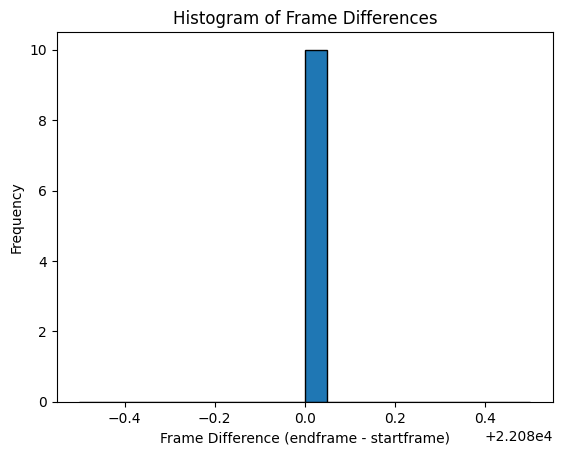

In [12]:
import matplotlib.pyplot as plt
print(expanded_df.columns)
expanded_df['frame_diff'] = expanded_df['endframe'] - expanded_df['startframe'] 
print(expanded_df['duration'].nsmallest(20))
filtered_df = expanded_df[expanded_df['frame_diff'] < 0]
print(filtered_df)
# Plot the histogram with 20 bins
plt.hist(expanded_df['frame_diff'], bins=20, edgecolor='black')
plt.title('Histogram of Frame Differences')
plt.xlabel('Frame Difference (endframe - startframe)')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [13]:
print(dir(model))


['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members', '_non_persistent_buffers_set', '_parameters', '_register_load_state_dict_pre_hoo

In [14]:
import meeteval
from meeteval.viz.visualize import AlignmentVisualization

folder = r'https://raw.githubusercontent.com/fgnt/meeteval/main/'
av = AlignmentVisualization(
    meeteval.io.load(folder + 'example_files/ref.stm').groupby('filename')['recordingA'],
    meeteval.io.load(folder + 'example_files/hyp.stm').groupby('filename')['recordingA']
)
display(av)  # Jupyter
av.dump('viz.html')  # Create standalone HTML file

In [5]:
import meeteval
import pandas as pd
import jiwer

# SISO WER
wer = meeteval.wer.wer.siso.siso_word_error_rate(
    reference='The quick brown fox jumps over the lazy dog',
    hypothesis='The qwick brown fox jump over lazy '
)
print(wer)
expanded_df = expanded_df.head(10)
print(dir(expanded_df['results'][0].__str__()))
print(expanded_df['results'][0].text)
print(expanded_df['words'][0])
print((expanded_df['results'].apply(type)))
def extract_text(result):
    # Assuming the DecodingResult object has a 'text' attribute
    return result.text

# Apply the extraction function to the 'results' column
expanded_df['results_text'] = expanded_df.apply(lambda row: row['results'].text, axis=1)
#expanded_df['duration'] = expanded_df.apply(lambda row: row['end'] - row['start'], axis=1)
print(type(expanded_df['results_text'][0]))
# Calculate WER using the extracted text
expanded_df['wer'] = expanded_df.apply(
    lambda row: meeteval.wer.wer.siso.siso_word_error_rate(
        reference=row['words'], 
        hypothesis=row['results_text']
    ), 
    axis=1
)
print(expanded_df['wer'])

from whisper.normalizers import EnglishTextNormalizer
data = pd.read_csv('/home/niklas/dipco_eval.csv')
normalizer = EnglishTextNormalizer()
data["hypothesis_clean"] = [normalizer(text) for text in data["results"]]
data["reference_clean"] = [normalizer(text) for text in data["words"]]
print(data.head)
wer = jiwer.wer(list(data["reference_clean"]), list(data["hypothesis_clean"]))

print(f"WER: {wer * 100:.2f} %")


<bound method NDFrame.head of                                                     words    start      end  \
0                                             speaker one    10.15    11.53   
1                                             speaker one    10.15    11.53   
2                                             speaker one    10.15    11.53   
3                                             speaker one    10.15    11.53   
4                                             speaker one    10.15    11.53   
...                                                   ...      ...      ...   
128550  yeah i remember growing up my high school was ...  1764.92  1793.46   
128551  yeah i remember growing up my high school was ...  1764.92  1793.46   
128552  yeah i remember growing up my high school was ...  1764.92  1793.46   
128553  yeah i remember growing up my high school was ...  1764.92  1793.46   
128554  yeah i remember growing up my high school was ...  1764.92  1793.46   

                     

In [6]:
print(data.sample(n=10))
data['wer'] = data.apply(
    lambda row: meeteval.wer.wer.siso.siso_word_error_rate(
        reference=row['reference_clean'], 
        hypothesis=row['hypothesis_clean']
    ), 
    axis=1
)

                                                    words    start      end  \
127133                                               hmmm   576.95   578.00   
22395                                           hmmm hmmm   282.79   283.45   
111686                                               yeah   959.45   960.32   
113969  education wise i guess this is much more syste...   327.48   330.51   
30125                                           the carbs  1919.43  1920.43   
36984                             did not qualify [noise]   508.46   515.88   
71094                                       like a arcade  1036.32  1037.83   
18353                                   you can't breathe  2139.43  2140.61   
19008                                                  oh  2358.98  2360.07   
31136                                                yeah  2112.46  2113.20   

                                                file_path  \
127133  /project/data_asr/dipco/Dipco/audio/dev/S02_P0...   
22395   

In [8]:
ascii_pattern = r'^[\x00-\x7F]*$'

# Step 3: Filter the DataFrame
print(data.shape)
df_ascii = data[data['hypothesis_clean'].str.contains(ascii_pattern, na=False)]
print (df_ascii.shape)
wer = jiwer.wer(list(df_ascii["reference_clean"]), list(df_ascii["hypothesis_clean"]))

print(f"WER: {wer * 100:.2f} %")

(128555, 12)
(123499, 12)
WER: 76.19 %


In [32]:
# looking at the results from the individual sessions 
import re 
def extract_session(file_path):
    match = re.search(r'/S(\d+)', file_path)
    if match:
        return int(match.group(1))
    else:
        return None
# the microphones on person vs not on person 
def extract_person(file_path):
    match = re.search(r'/S(\d+)_([PU])(\d+)', file_path)
    if match:
        return str(match.group(2))
    else:
        return None
# the people 
def extract_location(file_path):
    match = re.search(r'/S(\d+)_([PU])(\d+)', file_path)
    if match:
        return str(match.group(3))
    else:
        return None

def print_wer(grouped, type):
    for name, group in grouped:
    
        wer = jiwer.wer(list(group["reference_clean"]), list(group["hypothesis_clean"]))
        print(f"{type} {name}")
        print(f"wer {wer}")
        
        
    
data['session_number'] = data['file_path'].apply(extract_session)
data['mic_type'] = data['file_path'].apply(extract_person)
data['mic_number'] = data['file_path'].apply(extract_location)
grouped_ses = data.groupby('session_number')
print_wer(grouped_ses, "session")
grouped_mic_type = data.groupby('mic_type')
grouped_mic = data.groupby(['mic_type','mic_number'])
print_wer(grouped_mic, "mic_type")
print(wer)



    

    



session 2
wer 0.5949023800146289
session 4
wer 0.9523546525962818
session 5
wer 0.8507359924026591
session 9
wer 0.6844808616596213
session 10
wer 0.6322262903800667
mic_type ('P', '05')
wer 0.3541666666666667
mic_type ('P', '06')
wer 0.21905379131561892
mic_type ('P', '07')
wer 0.2781289506953224
mic_type ('P', '08')
wer 0.2037691401648999
mic_type ('P', '13')
wer 0.6682161533991865
mic_type ('P', '14')
wer 0.3517857142857143
mic_type ('P', '15')
wer 0.3089996137504828
mic_type ('P', '16')
wer 0.4468715290633099
mic_type ('P', '17')
wer 0.3641755634638197
mic_type ('P', '18')
wer 0.3074763074763075
mic_type ('P', '19')
wer 0.4615649775939331
mic_type ('P', '20')
wer 0.6018569087930092
mic_type ('P', '29')
wer 0.19761606022584693
mic_type ('P', '30')
wer 0.3226345703778001
mic_type ('P', '31')
wer 0.20342396777442096
mic_type ('P', '32')
wer 0.21593625498007968
mic_type ('U', '01')
wer 0.9129460510739049
mic_type ('U', '02')
wer 0.8055555555555556
mic_type ('U', '03')
wer 0.87454549298

Directory 'Figures' already exists.


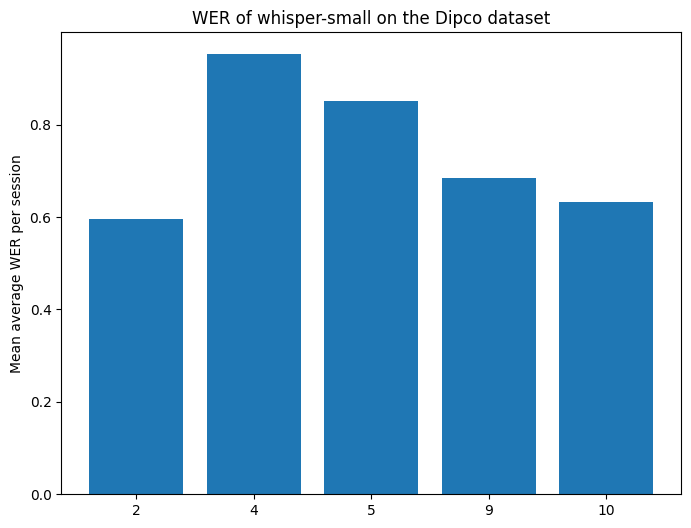

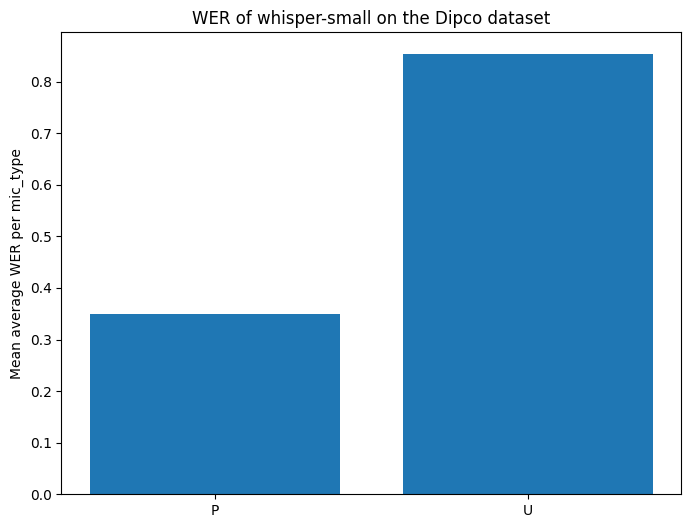

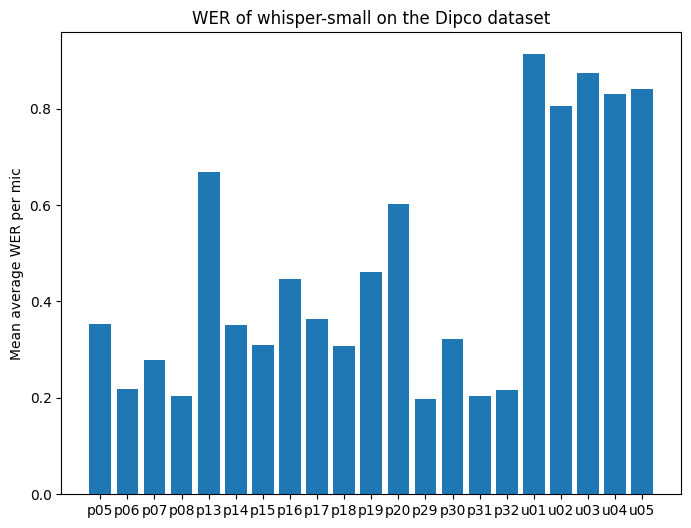

In [54]:
# plot visualization of the different sessions and store the results
import ast
import re
import matplotlib.pyplot as plt
def visualize_wer(grouped, type):
    names = []
    wers = []
    for name, group in grouped:
    
        wer = jiwer.wer(list(group["reference_clean"]), list(group["hypothesis_clean"]))
        

        # Regular expression to check if the string is a tuple representation
        tuple_pattern = r"\(\s*'[^']*'\s*,\s*'[^']*'\s*\)"
        
        # Check if the input string matches the tuple pattern
        if re.fullmatch(tuple_pattern, str(name)):
            # Safely evaluate the string to get the tuple
            parsed_tuple = ast.literal_eval(str(name))
        
            # Concatenate the elements and convert to lowercase
            result_str = f"{parsed_tuple[0].lower()}{parsed_tuple[1]}"
            names.append(result_str)
           
        else:
            names.append(str(name))
            
        
        wers.append(wer)
    plt.figure(figsize=(8, 6))
    plt.bar(names, wers)
    plt.ylabel(f'Mean average WER per {type[0]}')
    model_name = type[2].rsplit('/', 1)[-1]
    plt.title(f'WER of {model_name} on the {(dataset_name:=(type[1]))} dataset')
   
    plt.savefig(f'Figures/{(partition_type:=(type[0]))} bar_plot.png', format='png')
    plt.show()
    
directory = "Figures"

# Create the directory if it doesn't exist
if not os.path.exists(directory):
    os.makedirs(directory)
    print(f"Directory '{directory}' created.")
else:
    print(f"Directory '{directory}' already exists.")      
visualize_wer(grouped_ses, ["session", f"{dataset_name}", f"{model_name}"])
visualize_wer(grouped_mic_type, ["mic_type", f"{dataset_name}", f"{model_name}"])
visualize_wer(grouped_mic, ["mic", f"{dataset_name}", f"{model_name}"])



In [18]:
error_rates = data['wer'].apply(lambda x: x.error_rate)

# Calculate the mean of the error rates
mean_error_rate = error_rates.mean()
print(mean_error_rate)

1.3535045553024185


In [ ]:
import os
import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from torchaudio.transforms import Resample
from tqdm import tqdm

class DIPCODataset(Dataset):
    def __init__(self, root_dir, target_sample_rate=16000, transform=None):
        self.root_dir = root_dir
        self.file_paths = []
        for subdir, _, files in os.walk(root_dir):
            for file in files:
                if file.endswith('.wav'):
                    if file.startswith('._'):
                        pass
                    else:
                        self.file_paths.append(os.path.join(subdir, file))
                        
                    
        self.target_sample_rate = target_sample_rate
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform, sample_rate = torchaudio.load(file_path)
        
        # Resample if the sample rate is different from the target sample rate
        if sample_rate != self.target_sample_rate:
            waveform = Resample(orig_freq=sample_rate, new_freq=self.target_sample_rate)(waveform)

        if self.transform:
            waveform = self.transform(waveform)
        
        return waveform, file_path

def collate_fn(batch):
    waveforms, file_paths = zip(*batch)
    waveforms = [waveform.mean(dim=0, keepdim=True) for waveform in waveforms]  # Convert to mono
    return torch.cat(waveforms, dim=0), file_paths

# Parameters
root_dir = '/media/niklas/SSD/Dataset/Dipco/audio'
target_sample_rate = 16000
batch_size = 16
num_workers = 4

# Dataset and DataLoader
dataset = DIPCODataset(root_dir, target_sample_rate=target_sample_rate)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collate_fn)

# Example of iterating through the DataLoader


# Example of iterating through the DataLoader with a progress bar
'''
for waveforms, file_paths in tqdm(dataloader, total=len(dataloader), desc="Processing"):
    print(f'Batch size: {waveforms.size(0)}')
    for waveform, file_path in zip(waveforms, file_paths):
        print(f'Processed file: {file_path}')
    break  # Remove this line to iterate over the entire dataset
'''


In [ ]:
import torch
from torch.utils.data import Dataset
import soundfile as sf

class CustomAudioDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        wav_file_path = row['file_path']
        start_frame = row['startframe']
        end_frame = row['endframe']
        label = row['words']
        
        # Load the audio file segment
        audio, _ = sf.read(wav_file_path, start=start_frame, stop=end_frame)
        
        # Convert to tensor
        audio_tensor = torch.tensor(audio)
        
        return audio_tensor, label


In [ ]:
from torch.utils.data import DataLoader

# Create the dataset
audio_dataset = CustomAudioDataset(expanded_df)

# Create the dataloader
dataloader = DataLoader(audio_dataset, batch_size=2, shuffle=True)

# Example usage in a training loop
for batch in dataloader:
    inputs, labels = batch
    print(inputs, labels)
    # Your training code here


In [ ]:
from torch import optim
import whisper.tokenizer as tokenizer
tokenizer = tokenizer.get_tokenizer(multilingual=False, language='en')

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
def train(model, data_loader, optimizer, criterion, device, tokenizer):
    model.train()
    for batch in data_loader:
        audio, labels = batch
        audio = whisper.pad_or_trim(audio)
        audio = audio.to(device)
    
        # make log-Mel spectrogram and move to the same device as the model
        mel = whisper.log_mel_spectrogram(audio).to(model.device)
    
    
        # detect the spoken language
        #_, probs = model.detect_language(mel)
        #print(f"Detected language: {max(probs, key=probs.get)}")
    
        # decode the audio
        options = whisper.DecodingOptions()
        result = whisper.decode(model, mel, options)

        # Forward pass
        
        
        # Compute loss
        labels = tokenizer.encode(labels)
        loss = criterion(result[0].audio_features, labels)
        print(loss)
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CTCLoss()
train_loader = ()
for epoch in range(10):  # Number of epochs
    train(model, dataloader, optimizer, criterion, device, tokenizer=tokenizer)
    print(f"Epoch {epoch+1} completed")

# Save the model
torch.save(model.state_dict(), "fine_tuned_whisper.pth")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Index(['words', 'start', 'end', 'file_path', 'frames', 'duration',
       'startframe', 'endframe', 'results', 'frame_diff'],
      dtype='object')


In [ ]:
from transformers import Trainer, TrainingArguments
from torch.utils.data import DataLoader

class CustomTrainer(Trainer):
    def get_train_dataloader(self):
        return DataLoader(
            self.train_dataset, 
            batch_size=self.args.train_batch_size, 
            shuffle=True
        )

    def get_eval_dataloader(self, eval_dataset=None):
        if eval_dataset is None:
            eval_dataset = self.eval_dataset
        return DataLoader(
            eval_dataset, 
            batch_size=self.args.eval_batch_size
        )


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame
train_df, eval_df = train_test_split(expanded_df, test_size=0.2)

train_dataset = CustomAudioDataset(train_df)
eval_dataset = CustomAudioDataset(eval_df)


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [42]:
from huggingface_hub import notebook_login
#***REMOVED***
notebook_login()

In [56]:
from datasets import load_dataset, DatasetDict

common_voice = DatasetDict()

common_voice["train"] = load_dataset("mozilla-foundation/common_voice_11_0", "hi", split="train", use_auth_token=True)

/home/niklas/PycharmProjects/Whisper/.venv/lib/python3.10/site-packages/datasets/load.py:2554: FutureWarning: 'use_auth_token' was deprecated in favor of 'token' in version 2.14.0 and will be removed in 3.0.0.
You can remove this warning by passing 'token=<use_auth_token>' instead.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]


Reading metadata...: 4361it [00:00, 223865.27it/s]


Generating validation split: 0 examples [00:00, ? examples/s]


Reading metadata...: 2179it [00:00, 204639.14it/s]


...


Reading metadata...: 2894it [00:00, 179269.17it/s]


Generating other split: 0 examples [00:00, ? examples/s]


Reading metadata...: 3328it [00:00, 262129.23it/s]


Generating invalidated split: 0 examples [00:00, ? examples/s]


Reading metadata...: 680it [00:00, 244251.67it/s]


In [60]:
import inspect
inspect.getsource(DatasetDict)

'class DatasetDict(dict):\n    """A dictionary (dict of str: datasets.Dataset) with dataset transforms methods (map, filter, etc.)"""\n\n    def _check_values_type(self):\n        for dataset in self.values():\n            if not isinstance(dataset, Dataset):\n                raise TypeError(f"Values in `DatasetDict` should be of type `Dataset` but got type \'{type(dataset)}\'")\n\n    def _check_values_features(self):\n        items = list(self.items())\n        for item_a, item_b in zip(items[:-1], items[1:]):\n            if item_a[1].features != item_b[1].features:\n                raise ValueError(\n                    f"All datasets in `DatasetDict` should have the same features but features for \'{item_a[0]}\' and \'{item_b[0]}\' don\'t match: {item_a[1].features} != {item_b[1].features}"\n                )\n\n    def __enter__(self):\n        return self\n\n    def __exit__(self, exc_type, exc_val, exc_tb):\n        # Here `del` is used to del the pyarrow tables. This properly 

In [55]:
!pip install accelerate -U
!pip install transformers[torch]
from transformers import TrainingArguments
from transformers import AutoModelForAudioClassification, AutoFeatureExtractor
from datasets import load_dataset
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from transformers import WhisperTokenizer
from transformers import WhisperFeatureExtractor
from transformers import Seq2SeqTrainer
from transformers import Seq2SeqTrainingArguments
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-small", language="English", task="transcribe")

# Load the processor and model
#processor = WhisperProcessor.from_pretrained("openai/whisper-small")
minds = load_dataset("PolyAI/minds14", "en-US", split="train")
minds = minds.train_test_split(test_size=0.2)
minds = minds.remove_columns(["path", 'labels', "lang_id"])
dataset = minds
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

print(dataset.__dict__)



#feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")


def preprocess_function(examples):
    audio_arrays = [x for x in examples["audio"]]
    inputs = feature_extractor(
        audio_arrays, sampling_rate=feature_extractor.sampling_rate, 
    )
    return inputs
encoded_minds = minds
import evaluate

accuracy = evaluate.load("accuracy")
import numpy as np


def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=eval_pred.label_ids)

from transformers import AutoModelForAudioClassification, TrainingArguments, Trainer

model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
training_args = Seq2SeqTrainingArguments(
    output_dir="my_awesome_mind_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_minds["train"],
    eval_dataset=encoded_minds["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

#trainer.train()

#dataset = dataset.map(preprocess_function, batched=True)

print(expanded_df.columns)
dataset = dataset.rename_column("intent_class", "labels")
from torch.utils.data import DataLoader

dataset.set_format(type="torch", columns=["input_features", "labels"])
dataloader = DataLoader(dataset, batch_size=4)

'''from transformers import Trainer, Seq2SeqTrainer

trainer = Trainer(
    model=model,
   
    train_dataset=dataset,
    
    tokenizer=processor.feature_extractor,  # Assuming WhisperProcessor is used for tokenization
)

trainer.train()'''


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


ValueError: Column name ['labels'] not in the dataset. Current columns in the dataset: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id']

In [33]:
# untrained model just inference
import inspect
yesno_data = torchaudio.datasets.YESNO('.', download=True)
#print(dir(yesno_data))
source_code = inspect.getsource(yesno_data.__class_getitem__)
#print(source_code)
data_loader = torch.utils.data.DataLoader(
    yesno_data,
    batch_size=1,
    shuffle=True,   
    num_workers=4)
from datasets import Dataset
import transformers
source_code = inspect.signature(transformers.Trainer)
print(source_code)
import inspect
from transformers import WhisperFeatureExtractor

# Get the source code of the WhisperFeatureExtractor class
source_code = inspect.getsource(WhisperFeatureExtractor)
print(source_code)


(model: Union[transformers.modeling_utils.PreTrainedModel, torch.nn.modules.module.Module] = None, args: transformers.training_args.TrainingArguments = None, data_collator: Optional[transformers.data.data_collator.DataCollator] = None, train_dataset: Union[torch.utils.data.dataset.Dataset, torch.utils.data.dataset.IterableDataset, ForwardRef('datasets.Dataset'), NoneType] = None, eval_dataset: Union[torch.utils.data.dataset.Dataset, Dict[str, torch.utils.data.dataset.Dataset], ForwardRef('datasets.Dataset'), NoneType] = None, tokenizer: Optional[transformers.tokenization_utils_base.PreTrainedTokenizerBase] = None, model_init: Optional[Callable[[], transformers.modeling_utils.PreTrainedModel]] = None, compute_metrics: Optional[Callable[[transformers.trainer_utils.EvalPrediction], Dict]] = None, callbacks: Optional[List[transformers.trainer_callback.TrainerCallback]] = None, optimizers: Tuple[torch.optim.optimizer.Optimizer, torch.optim.lr_scheduler.LambdaLR] = (None, None), preprocess_l